# Trend Analysis

**EDA: Trend Analysis**

This notebook explores price trends for the companies currently loaded into
the SmartStock data warehouse: closing price over time, moving averages, and
period-over-period returns.

In [1]:
# Add the project root to the path so we can reuse the existing database
# connection module (src/utils/database.py) instead of duplicating
# connection logic in this notebook.
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import warnings
import pandas as pd
import matplotlib.pyplot as plt

# pandas warns that psycopg2 connections aren't officially "tested" for
# read_sql; this is a known, harmless warning when using our psycopg2-based
# connection module (src/utils/database.py) instead of SQLAlchemy, and is
# safe to suppress here.
warnings.filterwarnings("ignore", message=".*only supports SQLAlchemy.*")

from src.utils.database import get_connection

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load Data

Pull all companies and their full price history from the warehouse.

In [2]:
with get_connection() as conn:
    companies_df = pd.read_sql(
        "SELECT company_id, symbol, company_name, sector FROM companies ORDER BY symbol;",
        conn,
    )
    prices_df = pd.read_sql(
        """
        SELECT hp.company_id, c.symbol, hp.date, hp.open, hp.high, hp.low, hp.close, hp.volume
        FROM historical_prices hp
        JOIN companies c ON c.company_id = hp.company_id
        ORDER BY c.symbol, hp.date;
        """,
        conn,
    )

prices_df["date"] = pd.to_datetime(prices_df["date"])
print(f"Loaded {len(companies_df)} companies and {len(prices_df)} price rows.")
companies_df

Loaded 5 companies and 1825 price rows.


,company_id,symbol,company_name,sector
0,1,AAPL,Apple Inc,Technology
1,3,GOOGL,Alphabet Inc,Media
2,7,JPM,JPMorgan Chase & Co,Banking
3,2,MSFT,Microsoft Corp,Technology
4,8,XOM,Exxon Mobil Corp,Energy


## 2. Closing Price Trend Per Symbol

A simple line plot of closing price over time for every symbol currently in
the warehouse, so multiple companies can be compared on the same chart.

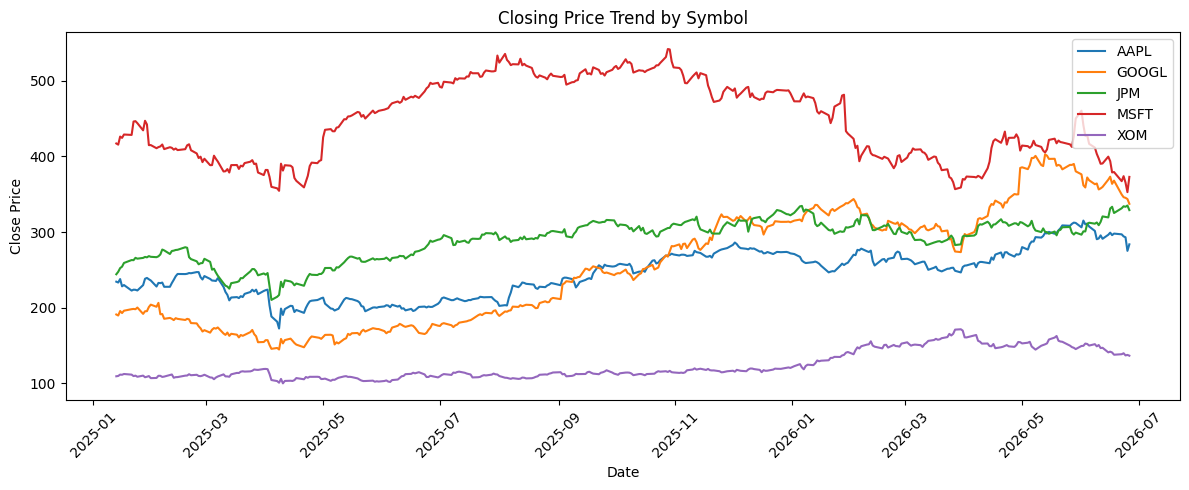

In [3]:
if prices_df.empty:
    print("No price data found. Run the ingestion + ETL pipeline first (see the prerequisite note above).")
else:
    fig, ax = plt.subplots()
    for symbol, group in prices_df.groupby("symbol"):
        ax.plot(group["date"], group["close"], label=symbol)
    ax.set_title("Closing Price Trend by Symbol")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 3. Moving Averages (SMA-7 / SMA-20)

Short and medium simple moving averages are a standard first step in trend
analysis: when the short-window average is above the long-window average,
the trend is generally considered upward, and vice versa.

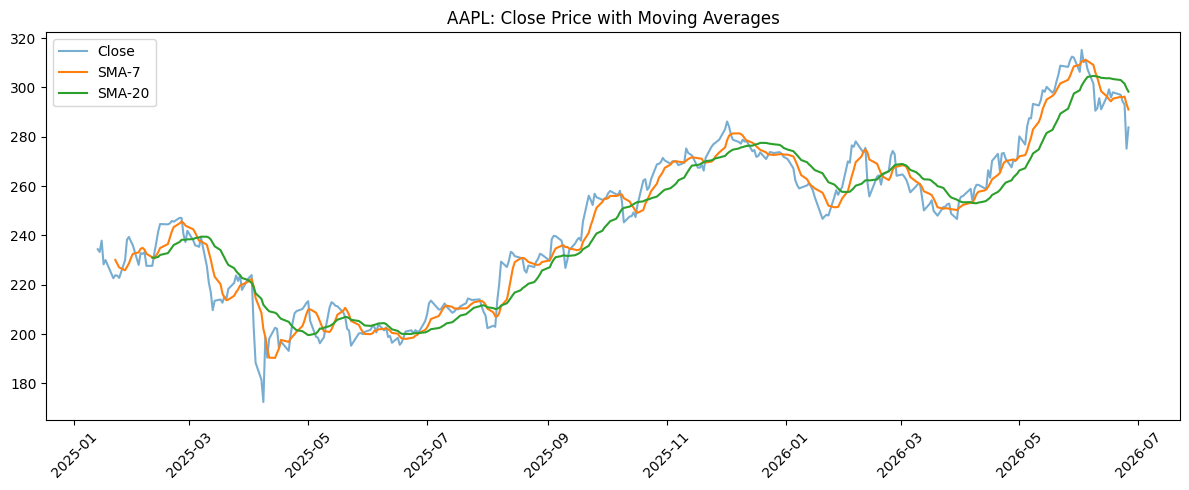

In [4]:
def add_moving_averages(df: pd.DataFrame, short_window: int = 7, long_window: int = 20) -> pd.DataFrame:
    """Add SMA columns to a single symbol's price DataFrame, sorted by date."""
    df = df.sort_values("date").copy()
    df[f"sma_{short_window}"] = df["close"].rolling(window=short_window).mean()
    df[f"sma_{long_window}"] = df["close"].rolling(window=long_window).mean()
    return df


if not prices_df.empty:
    symbols = prices_df["symbol"].unique()
    target_symbol = symbols[0]  # change this to inspect a different symbol
    symbol_df = add_moving_averages(prices_df[prices_df["symbol"] == target_symbol])

    fig, ax = plt.subplots()
    ax.plot(symbol_df["date"], symbol_df["close"], label="Close", alpha=0.6)
    ax.plot(symbol_df["date"], symbol_df["sma_7"], label="SMA-7")
    ax.plot(symbol_df["date"], symbol_df["sma_20"], label="SMA-20")
    ax.set_title(f"{target_symbol}: Close Price with Moving Averages")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    symbol_df.tail()

## 4. Period-over-Period Returns

Daily percentage change in closing price, and the cumulative return over the
loaded date range — a quick read on which symbols have trended up or down
the most overall.

In [5]:
if not prices_df.empty:
    returns_df = prices_df.sort_values(["symbol", "date"]).copy()
    returns_df["daily_return_pct"] = returns_df.groupby("symbol")["close"].pct_change() * 100

    cumulative_returns = (
        returns_df.groupby("symbol")
        .apply(lambda g: (g["close"].iloc[-1] / g["close"].iloc[0] - 1) * 100, include_groups=False)
        .rename("cumulative_return_pct")
        .sort_values(ascending=False)
    )
    cumulative_returns

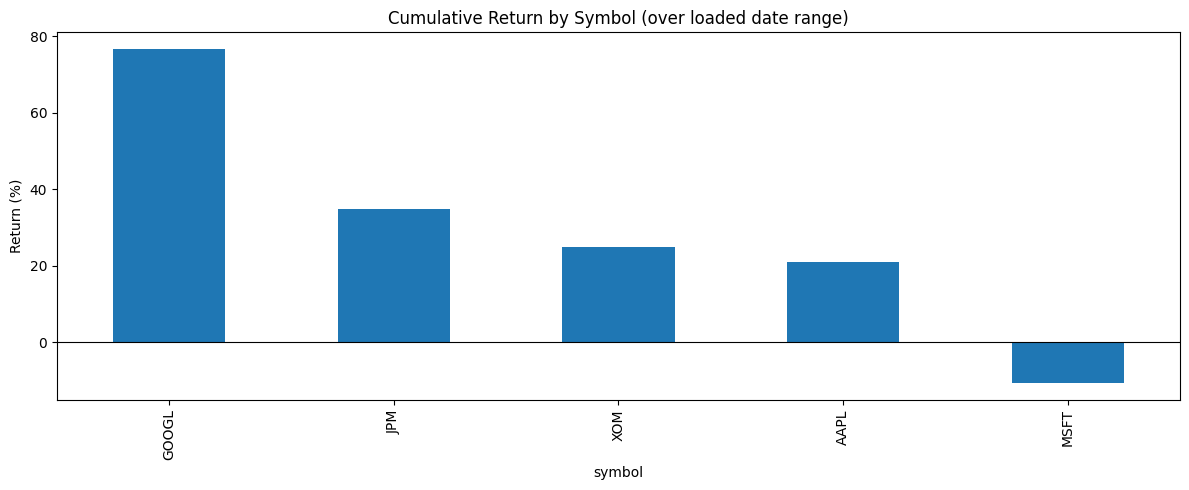

In [6]:
if not prices_df.empty:
    fig, ax = plt.subplots()
    cumulative_returns.plot(kind="bar", ax=ax)
    ax.set_title("Cumulative Return by Symbol (over loaded date range)")
    ax.set_ylabel("Return (%)")
    ax.axhline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()